<a href="https://colab.research.google.com/github/BabuShaik778/forecast_task/blob/main/LSTM_forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#  Import Libraries
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
import joblib
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import LSTM, Dense, Dropout


from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.preprocessing import MinMaxScaler

import joblib
import xgboost as xgb


In [ ]:
# =========================
# 2. Load Data
# =========================
df = pd.read_csv("price_data (1).csv", parse_dates=["date"])
df.set_index("date", inplace=True)

print(df.head())
print(df.info())

In [24]:
print(df.tail())
print(df.describe())

            avg_monthly_price
date                         
2025-05-01              14263
2025-06-01              14263
2025-07-01              16000
2025-08-01              15025
2025-09-01              15750
       avg_monthly_price
count         249.000000
mean         7918.891566
std          2804.992684
min          3500.000000
25%          6123.000000
50%          7250.000000
75%          9783.000000
max         16163.000000


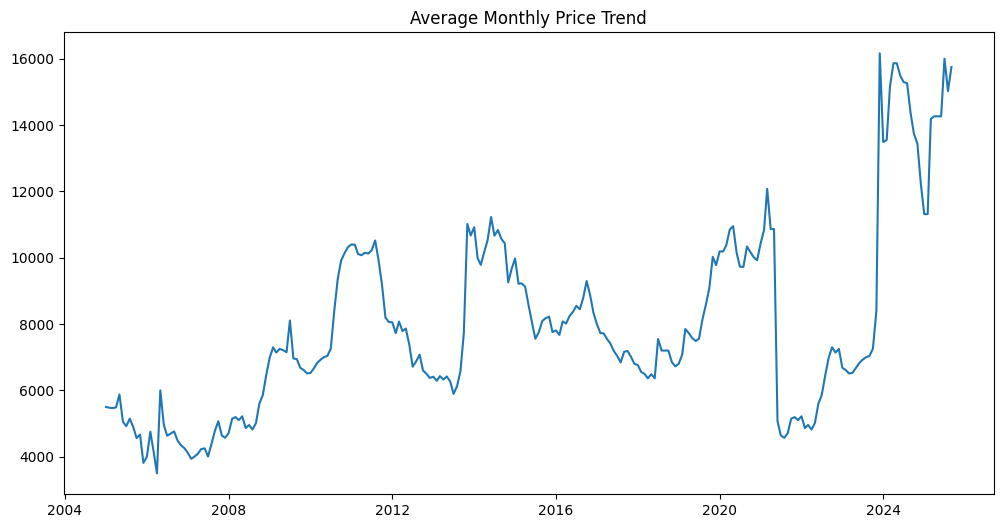

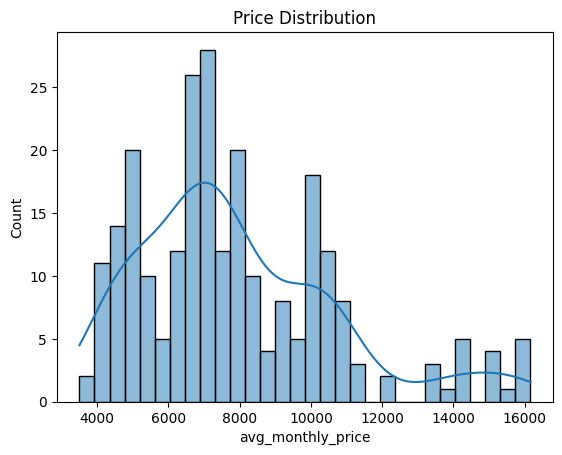

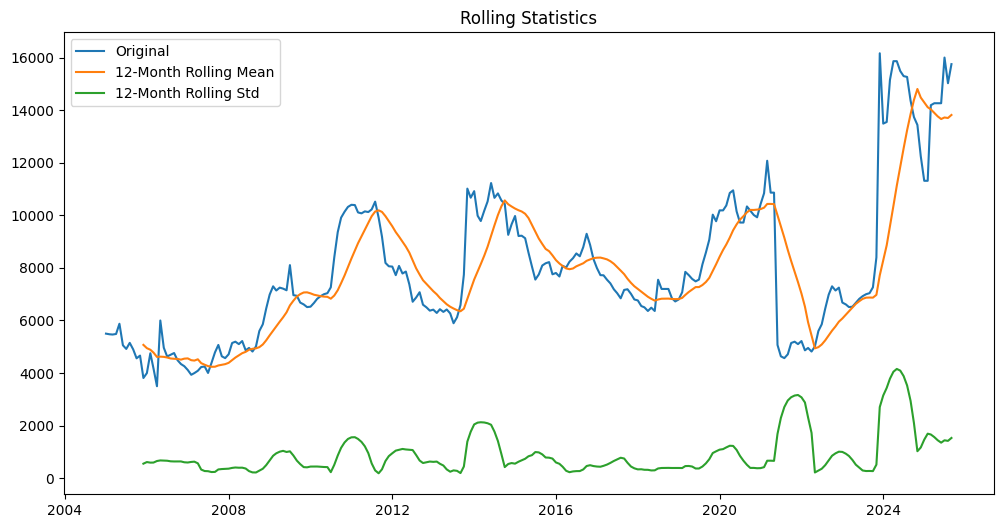

In [25]:

# 3. Exploratory Data Analysis (EDA)
# =========================
plt.figure(figsize=(12,6))
plt.plot(df.index, df['avg_monthly_price'])
plt.title("Average Monthly Price Trend")
plt.show()

sns.histplot(df['avg_monthly_price'], bins=30, kde=True)
plt.title("Price Distribution")
plt.show()

df['rolling_mean'] = df['avg_monthly_price'].rolling(window=12).mean()
df['rolling_std'] = df['avg_monthly_price'].rolling(window=12).std()

plt.figure(figsize=(12,6))
plt.plot(df['avg_monthly_price'], label='Original')
plt.plot(df['rolling_mean'], label='12-Month Rolling Mean')
plt.plot(df['rolling_std'], label='12-Month Rolling Std')
plt.legend()
plt.title("Rolling Statistics")
plt.show()


In [26]:
# =========================
# 4. Data Cleaning
# =========================
print("Missing values:", df.isnull().sum())
df['clean_price'] = df['avg_monthly_price'].rolling(window=3, min_periods=1).mean()


Missing values: avg_monthly_price     0
rolling_mean         11
rolling_std          11
dtype: int64


In [27]:
# =========================
# 5. Train-Test Split
# =========================
train = df.loc[:'2024-12-01', 'clean_price']
test = df.loc['2025-01-01':, 'clean_price']

print("Train size:", len(train))
print("Test size:", len(test))


Train size: 240
Test size: 9


In [28]:
# ============
# 6. Feature Engineering
# =========================
df['month'] = df.index.month
df['year'] = df.index.year
df['lag1'] = df['clean_price'].shift(1)
df['lag3'] = df['clean_price'].shift(3)
df['lag6'] = df['clean_price'].shift(6)
df['lag12'] = df['clean_price'].shift(12)
df['rolling_mean_3'] = df['clean_price'].rolling(window=3).mean()
df['rolling_mean_6'] = df['clean_price'].rolling(window=6).mean()
df['rolling_mean_12'] = df['clean_price'].rolling(window=12).mean()
df = df.dropna()

train_ml = df.loc[:'2024-12-01']
test_ml = df.loc['2025-01-01':]

X_train_ml = train_ml[['month','year','lag1','lag3','lag6','lag12','rolling_mean_3','rolling_mean_6','rolling_mean_12']]
y_train_ml = train_ml['clean_price']
X_test_ml = test_ml[['month','year','lag1','lag3','lag6','lag12','rolling_mean_3','rolling_mean_6','rolling_mean_12']]
y_test_ml = test_ml['clean_price']




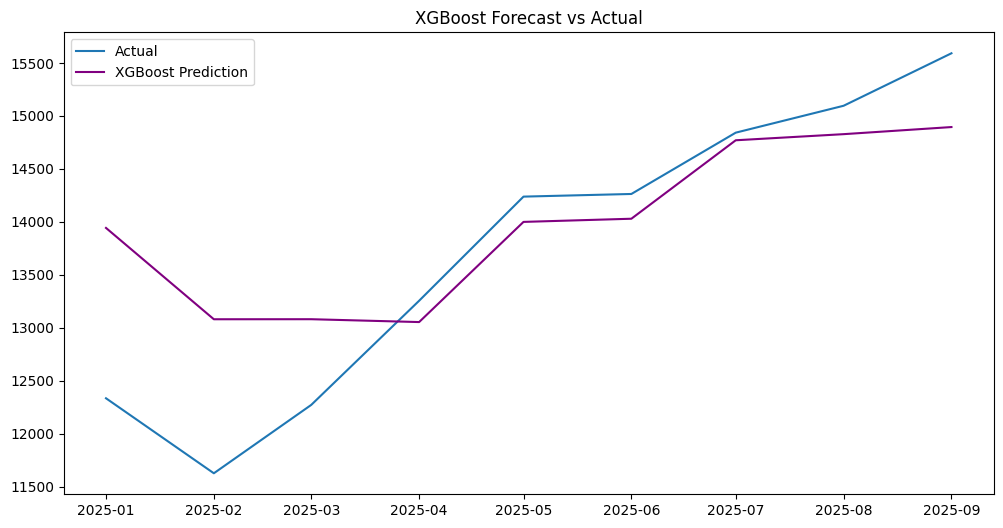

In [29]:


# =========================
# 7. XGBoost Model
# =========================
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=1000,          # number of boosting rounds
    learning_rate=0.05,        # conservative learning rate
    max_depth=6,               # tree depth
    subsample=0.8,             # row sampling
    colsample_bytree=0.8,      # feature sampling
    reg_alpha=0.1,             # L1 regularization
    reg_lambda=1.0,            # L2 regularization
    random_state=42,
    eval_metric="rmse"         # evaluation metric
)

# Fit model (no early stopping, stable across versions)
xgb_model.fit(X_train_ml, y_train_ml)

# Predictions
y_pred_xgb = xgb_model.predict(X_test_ml)

# Plot results
plt.figure(figsize=(12,6))
plt.plot(y_test_ml.index, y_test_ml, label="Actual")
plt.plot(y_test_ml.index, y_pred_xgb, label="XGBoost Prediction", color="purple")
plt.legend()
plt.title("XGBoost Forecast vs Actual")
plt.show()


Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - loss: 0.0355 - mae: 0.1500 - val_loss: 0.0372 - val_mae: 0.1242
Epoch 2/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0107 - mae: 0.0813 - val_loss: 0.0342 - val_mae: 0.1688
Epoch 3/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0123 - mae: 0.0829 - val_loss: 0.0263 - val_mae: 0.1146
Epoch 4/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0099 - mae: 0.0830 - val_loss: 0.0256 - val_mae: 0.1283
Epoch 5/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0095 - mae: 0.0743 - val_loss: 0.0251 - val_mae: 0.1261
Epoch 6/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0089 - mae: 0.0791 - val_loss: 0.0243 - val_mae: 0.1216
Epoch 7/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0090 - mae: 0.0717 - val_loss: 0.0235 - val_mae: 0.1191
Epoch 8/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0082 - mae: 0.0718 - val_loss: 0.0228 - val_mae: 0.1114
Epoch 9/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0074 - mae: 0.0647 - val

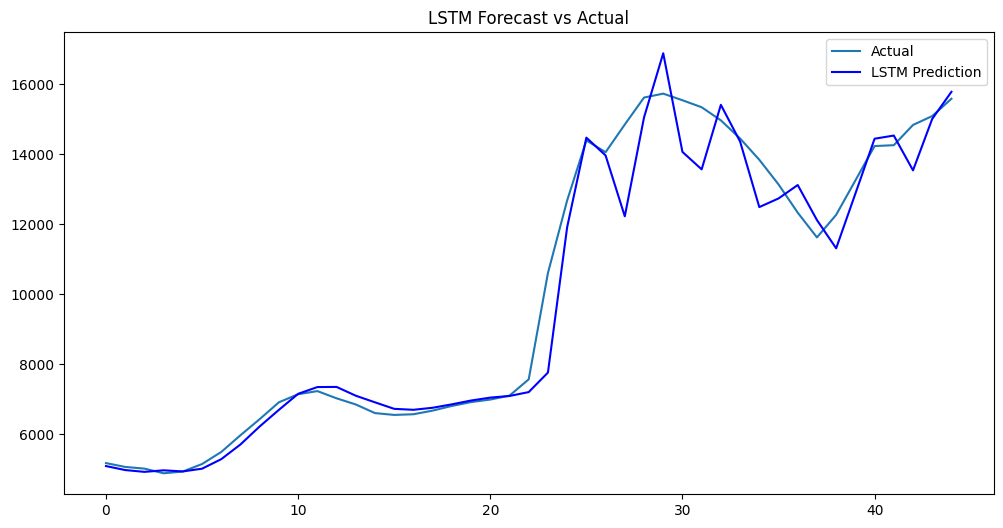

In [30]:
# =========================
# 8. LSTM Model
# =========================

# Scale
scaler = MinMaxScaler()
scaled_series = scaler.fit_transform(df[['clean_price']])

# Create sequences
def create_sequences(data, seq_length=12):
    X, y = [], []
    for i in range(len(data)-seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 12
X_all, y_all = create_sequences(scaled_series, seq_length)

split_index = int(len(X_all) * 0.8)
X_train_seq, X_test_seq = X_all[:split_index], X_all[split_index:]
y_train_seq, y_test_seq = y_all[:split_index], y_all[split_index:]

X_train_seq = X_train_seq.reshape((X_train_seq.shape[0], seq_length, 1))
X_test_seq = X_test_seq.reshape((X_test_seq.shape[0], seq_length, 1))

# LSTM Model
lstm_model = Sequential([
    LSTM(100, activation='tanh', return_sequences=True, input_shape=(seq_length,1)),
    Dropout(0.2),
    LSTM(50, activation='tanh'),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# Train
history = lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=300,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Predict
y_pred_lstm = lstm_model.predict(X_test_seq)
y_pred_lstm = scaler.inverse_transform(y_pred_lstm)
y_test_seq = scaler.inverse_transform(y_test_seq.reshape(-1,1))

# Plot
plt.figure(figsize=(12,6))
plt.plot(range(len(y_test_seq)), y_test_seq, label="Actual")
plt.plot(range(len(y_pred_lstm)), y_pred_lstm.flatten(), label="LSTM Prediction", color="blue")
plt.legend()
plt.title("LSTM Forecast vs Actual")
plt.show()

In [31]:

# =========================
# 9. Evaluation Metrics
# =========================

# --- XGBoost ---

import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

rmse_xgb = np.sqrt(mean_squared_error(y_test_ml, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test_ml, y_pred_xgb)
mape_xgb = mean_absolute_percentage_error(y_test_ml, y_pred_xgb)
r2_xgb = r2_score(y_test_ml, y_pred_xgb)

print("XGBoost Metrics:")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"MAE: {mae_xgb:.2f}")
print(f"MAPE: {mape_xgb:.2%}")
print(f"R²: {r2_xgb:.2f}")

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
import numpy as np

# --- LSTM Metrics ---
rmse_lstm = np.sqrt(mean_squared_error(y_test_seq, y_pred_lstm))
mae_lstm = mean_absolute_error(y_test_seq, y_pred_lstm)
mape_lstm = mean_absolute_percentage_error(y_test_seq, y_pred_lstm)
r2_lstm = r2_score(y_test_seq, y_pred_lstm)

print("LSTM Metrics:")
print(f"RMSE: {rmse_lstm:.2f}")
print(f"MAE: {mae_lstm:.2f}")
print(f"MAPE: {mape_lstm:.2%}")
print(f"R²: {r2_lstm:.2f}")

XGBoost Metrics:
RMSE: 821.42
MAE: 620.31
MAPE: 4.86%
R²: 0.62
LSTM Metrics:
RMSE: 806.92
MAE: 481.24
MAPE: 4.16%
R²: 0.96


Next 12 months forecast (XGBoost):
[15226.368 14479.977 13658.474 12331.682 11630.068 12265.553 13254.821
 14239.319 14268.582 14838.811 15098.641 15587.658]


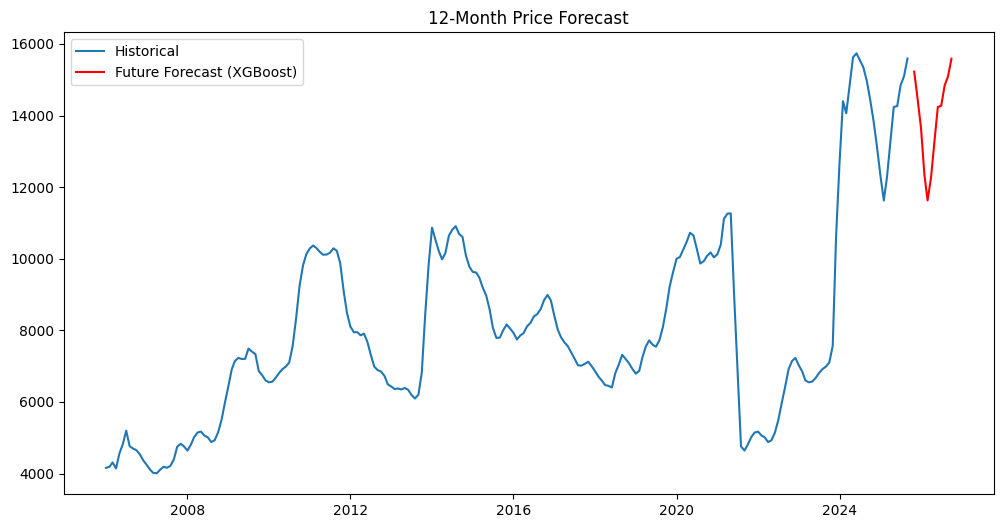

In [46]:
from xgboost import XGBRegressor

df['month'] = df.index.month
df['year'] = df.index.year
X = df[['month','year']]
y = df['clean_price']

model = XGBRegressor(n_estimators=100)
model.fit(X, y)

future_dates = pd.date_range(df.index[-1] + pd.DateOffset(months=1), periods=12, freq='ME')
future_df = pd.DataFrame({'month': future_dates.month, 'year': future_dates.year})
future_pred = model.predict(future_df)

print("Next 12 months forecast (XGBoost):")
print(future_pred)

plt.figure(figsize=(12,6))
plt.plot(df.index, df['clean_price'], label="Historical")
plt.plot(future_dates, future_pred, label="Future Forecast (XGBoost)", color="red")
plt.legend()
plt.title("12-Month Price Forecast")
plt.show()


In [49]:
import joblib

# Save XGBoost model
joblib.dump(xgb_model, "xgb_model.pkl")

# Save LSTM model
lstm_model.save("lstm_model.h5")


In [50]:
import tensorflow as tf
print(tf.__version__)


2.19.0
